In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
working_directory = "/Users/kemalinecik/git_nosync/sctram"

In [3]:
import sys
sys.path.append(working_directory)

import logging
import os
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
from sctram.generate.real import sc_norman_sciplex_cpa

sc.settings.verbosity = 3

In [4]:
from sctram.infer._paga import PAGAInference
from sctram.evaluate._adjacency import AdjacencyMatrixEvaluation
from sctram.input import read_dict

In [5]:
%matplotlib inline
%config InlineBackend.figure_format='retina'
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, 'rb') as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [6]:
dataset_dir = "/Users/kemalinecik/git_nosync/sctram/__temp__/data"
adata_norman = sc_norman_sciplex_cpa(dataset_dir=dataset_dir)
adata_bms = adata_norman[["bms" in i.lower() or "vehicle" in i.lower() for i in adata_norman.obs["drug"]]]

2025-02-06 13:16:52.410 | WARNING  | sctram.generate.real._download:download_dataset:105 - File PosixPath('/Users/kemalinecik/git_nosync/sctram/__temp__/data/norman_sciplex_cpa.h5ad') already exists. Skipping download.


# Input

In [7]:
ground_truth_trajectories = {
    "trajectory_1": [
        ('Vehicle_1.0', 'BMS_0.001'),
        ('BMS_0.001', 'BMS_0.005'),
        ('BMS_0.005', 'BMS_0.01'),
        ('BMS_0.01', 'BMS_0.05'),
        ('BMS_0.05', 'BMS_0.1'),
        ('BMS_0.1', 'BMS_0.5'),
        ('BMS_0.5', 'BMS_1.0'),
    ],
}
input_trajectories_all = read_dict(ground_truth_trajectories)
input_trajectories = input_trajectories_all.get_trajectory("trajectory_1", include_additional_nodes=False)

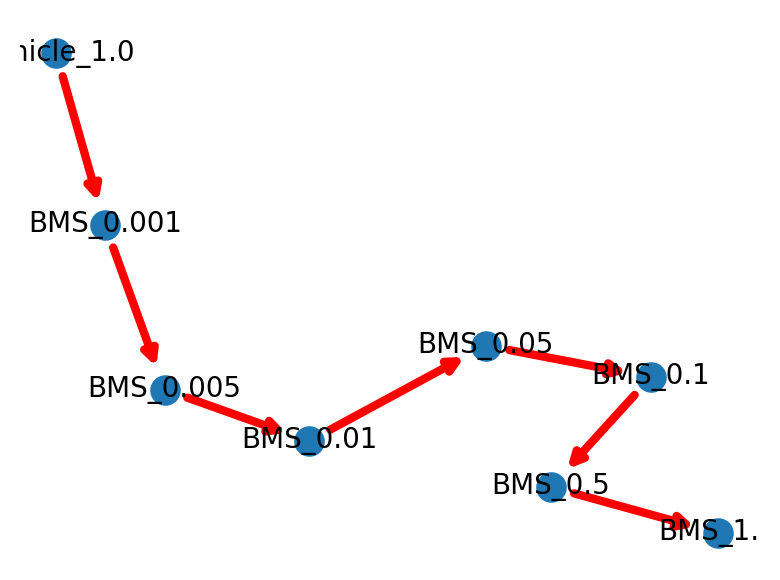

In [8]:
plt.figure(figsize=(4,3))
pos = nx.spring_layout(input_trajectories)  # positions for all nodes
nx.draw_networkx_nodes(input_trajectories, pos, node_size=100)
for u, v, data in input_trajectories.edges(data=True):
    nx.draw_networkx_edges(input_trajectories, pos, edgelist=[(u, v)], width=3, edge_color='red')
nx.draw_networkx_labels(input_trajectories, pos, font_size=10)
plt.axis("off")
plt.tight_layout()
plt.show()

# PAGA

In [9]:
adata = ad.AnnData(X=adata_bms.obsm["tardis"].copy(), obs=adata_bms.obs.copy())
paga_inference = PAGAInference(
    random_state=42, 
    neighbors_params={"n_neighbors": 90}, 
    adata=adata, 
    labels=adata.obs["drug_dose_name"]
)
paga_inference.calculate()
# the same operation in the `infer` example notebook.

2025-02-06 13:16:52.704 | DEBUG    | sctram.infer._base:_initialize_from_adata_without_neighbors:160 - Initializing from AnnData without precomputed neighbors.
2025-02-06 13:16:52.705 | DEBUG    | sctram.infer._base:_add_labels_to_adata:219 - Adding provided labels to AnnData object.
2025-02-06 13:16:52.706 | INFO     | sctram.infer._base:_initialize_from_adata_without_neighbors:167 - No precomputed neighbors found in AnnData.
2025-02-06 13:16:52.706 | DEBUG    | sctram.infer._base:_initialize_from_adata_without_neighbors:171 - AnnData initialized successfully from AnnData without neighbors.
2025-02-06 13:16:52.706 | INFO     | sctram.infer._base:calculate:495 - Starting PAGAInference trajectory inference.
2025-02-06 13:16:52.707 | INFO     | sctram.infer._base:calculate:498 - Performing trajectory inference.
2025-02-06 13:16:52.707 | INFO     | sctram.infer._base:_needs_neighbors:513 - Computing neighbors.


computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)
running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)


2025-02-06 13:16:56.021 | INFO     | sctram.infer._base:calculate:502 - Trajectory inference completed successfully.


In [10]:
inferred_trajectories = paga_inference.get_result("adjacency")
inferred_trajectories_labels = paga_inference.get_result("labels")

In [11]:
adjacency_evaluation = AdjacencyMatrixEvaluation(
    method_params = dict(
        metrics = [
            "frobenius",
            "L1",
            "accuracy",
            "graph_edit_distance",
            "spectral_distance",
            "jaccard",
            "hamming",
            "precision",
            "recall",
            "f1_score",
            "mantel_correlation",
            "ssim",
            "avg_shortest_path_diff",
            "degree_emd",
            "clustering_coeff_diff",
            "graphlet_degree_vector",
            "weisfeiler_lehman_distance",
            "gnn_embedding_distance",
            "persistence_diagram_distance",
            "maximum_common_subgraph_distance",
            "random_walk_kernel_distance",
        ]
    )
)

2025-02-06 13:16:56.105 | DEBUG    | sctram.evaluate._adjacency:__init__:38 - Initialized AdjacencyMatrixEvaluation with metrics: ['frobenius', 'L1', 'accuracy', 'graph_edit_distance', 'spectral_distance', 'jaccard', 'hamming', 'precision', 'recall', 'f1_score', 'mantel_correlation', 'ssim', 'avg_shortest_path_diff', 'degree_emd', 'clustering_coeff_diff', 'graphlet_degree_vector', 'weisfeiler_lehman_distance', 'gnn_embedding_distance', 'persistence_diagram_distance', 'maximum_common_subgraph_distance', 'random_walk_kernel_distance']


In [12]:
logging.getLogger().setLevel(logging.DEBUG)
try:
    adjacency_evaluation.evaluate(
        given_trajectory=input_trajectories,
        inferred_trajectory=inferred_trajectories,
        labels=inferred_trajectories_labels
    )
finally:
    logging.getLogger().setLevel(logging.INFO)

2025-02-06 13:16:56.135 | INFO     | sctram.evaluate._base:evaluate:159 - Starting evaluation with AdjacencyMatrixEvaluation.
2025-02-06 13:16:56.136 | DEBUG    | sctram.evaluate._base:evaluate:162 - Verifying given trajectory.
2025-02-06 13:16:56.136 | DEBUG    | sctram.evaluate._base:evaluate:165 - Verifying inferred trajectory.
2025-02-06 13:16:56.137 | DEBUG    | sctram.evaluate._base:evaluate:169 - Verifying labels.
2025-02-06 13:16:56.137 | DEBUG    | sctram.evaluate._adjacency:_verify_labels_data_specific:92 - Checking the consistency between the given graph and labels.
2025-02-06 13:16:56.137 | DEBUG    | sctram.evaluate._base:evaluate:175 - Preparing trajectories before subsetting.
2025-02-06 13:16:56.138 | DEBUG    | sctram.evaluate._adjacency:_prepare_before_subset:110 - Converting given trajectory to adjacency matrix.
2025-02-06 13:16:56.138 | DEBUG    | sctram.evaluate._adjacency:_prepare_before_subset:112 - Given adjacency matrix shape: (8, 8)
2025-02-06 13:16:56.139 | DE

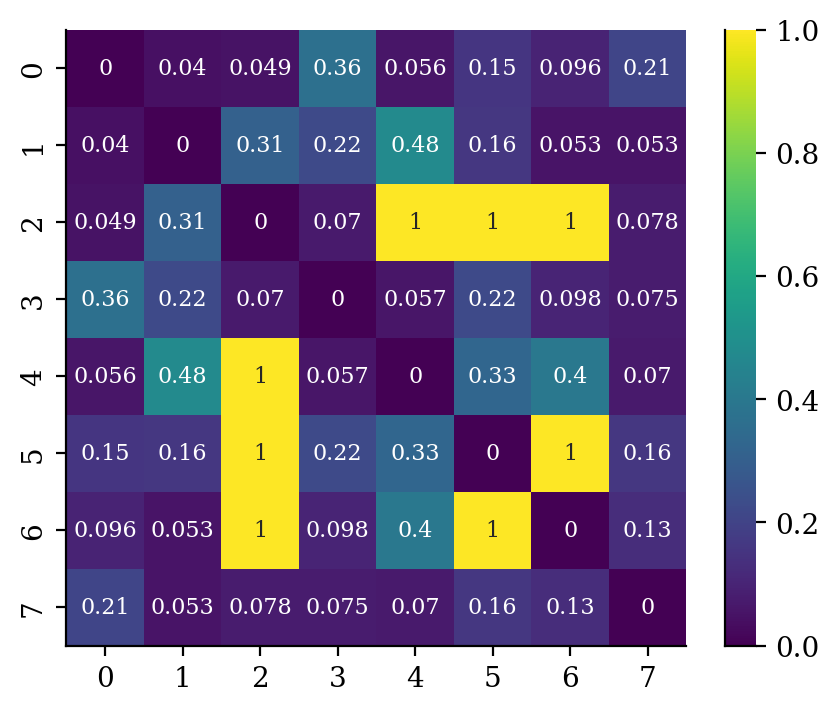

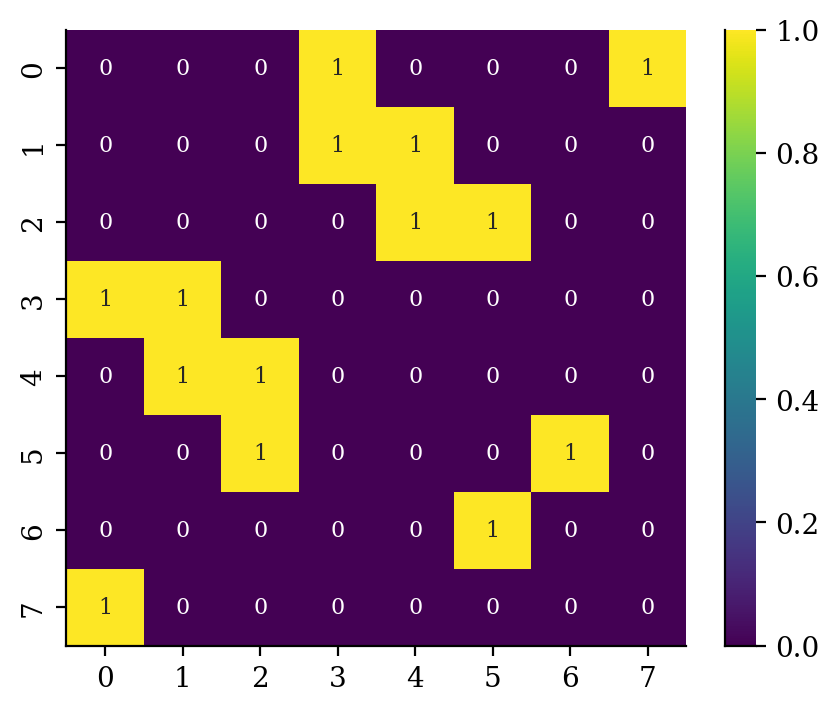

In [13]:
plt.figure(figsize=(5, 4))
sns.heatmap(adjacency_evaluation.prepared_after_subset_inferred, cmap='viridis', annot=True, annot_kws={"fontsize": 8})
sns.despine()
plt.show()
plt.figure(figsize=(5, 4))
sns.heatmap(adjacency_evaluation.prepared_after_subset_given, cmap='viridis', annot=True, annot_kws={"fontsize": 8})
sns.despine()
plt.show()

In [14]:
adjacency_evaluation.get_result()

{'frobenius': 2.635131946587082,
 'L1': 12.764002132770933,
 'accuracy': 0.21875,
 'graph_edit_distance': 21.0,
 'spectral_distance': 1.8115596591989842,
 'jaccard': 0.25,
 'hamming': 50,
 'precision': 0.75,
 'recall': 0.42857142857142855,
 'f1_score': 0.5454545454545454,
 'mantel_correlation': 0.6002613952614209,
 'ssim': 0.6153278686369203,
 'avg_shortest_path_diff': 2.0,
 'degree_emd': 0.6915345233413016,
 'clustering_coeff_diff': 1.0,
 'graphlet_degree_vector': 0.03125,
 'weisfeiler_lehman_distance': 618524180,
 'gnn_embedding_distance': 1.0000001,
 'persistence_diagram_distance': 0.0,
 'maximum_common_subgraph_distance': 35,
 'random_walk_kernel_distance': 0.27913136397372007}